Using cache found in /Users/diegobernalm1/.cache/torch/hub/facebookresearch_detr_main


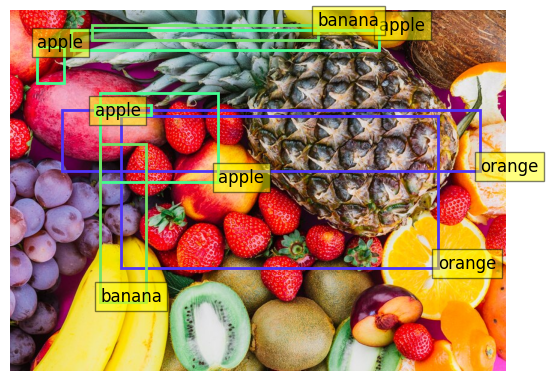

In [16]:
import torch
import torchvision.transforms as T
from PIL import Image
import requests
import matplotlib.pyplot as plt
import numpy as np

# Descargar imagen de ejemplo (puedes cambiarla por una tuya)
url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
#image = Image.open(requests.get(url, stream=True).raw)
image = Image.open("uno/f5.jpg")

# Transformación para la imagen
transform = T.Compose([
    T.Resize(800),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
img_tensor = transform(image).unsqueeze(0)

# Cargar modelo DETR preentrenado
model = torch.hub.load('facebookresearch/detr', 'detr_resnet50', pretrained=True)
model.eval()

# Realizar inferencia
with torch.no_grad():
    outputs = model(img_tensor)

# Umbral de confianza
probas = outputs['pred_logits'].softmax(-1)[0, :, :-1]
keep = probas.max(-1).values > 0.9

# Obtener cajas y etiquetas
labels = probas[keep].argmax(-1)
boxes = outputs['pred_boxes'][0, keep]

# Función para convertir las coordenadas de la caja (normalizadas -> píxeles)
def rescale_bboxes(bboxes, size):
    img_w, img_h = size
    b = bboxes.clone()
    b[:, 0] *= img_w
    b[:, 2] *= img_w
    b[:, 1] *= img_h
    b[:, 3] *= img_h
    return b

# Dibujar los resultados
CLASSES = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A',
    'backpack', 'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase',
    'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat',
    'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon',
    'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot',
    'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant',
    'bed', 'N/A', 'dining table', 'N/A', 'N/A', 'toilet', 'N/A',
    'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A',
    'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]

colors = np.random.rand(91, 3)  # 91 clases en COCO (incluyendo 'no object')
boxes = rescale_bboxes(boxes, image.size)

plt.imshow(image)
ax = plt.gca()

for box, label in zip(boxes, labels):
    color = colors[label]
    x, y, w, h = box.tolist()
    ax.add_patch(plt.Rectangle((x, y), w - x, h - y, fill=False, color=color, linewidth=2))
    ax.text(x, y, CLASSES[label], fontsize=12, bbox=dict(facecolor='yellow', alpha=0.5))
plt.axis('off')
plt.show()


In [6]:
CLASSES = requests.get('https://raw.githubusercontent.com/facebookresearch/detectron2/main/detectron2/data/datasets/COCO_NAMES.txt').text.splitlines()

In [7]:
CLASSES

['404: Not Found']